## Fetch lightcurves with Lasair

In [2]:
import numpy as np
import pandas as pd

tns_filename = 'tables/tns_public_objects_until_20250916.csv'
tns = pd.read_csv(tns_filename, header=0)
tns = tns[np.logical_and(tns['redshift'] <= 0.05, tns['declination'] > -60)]

sn_typeids = [4, 5, 6, 7, 9, 106]  # SN Ib, Ic, Ib/c, Ic-BL, Ibn, Ia-CSM
tns_ibc = tns[np.isin(tns['typeid'], sn_typeids)]

tns_ibc

,objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,...,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
223,186785,SN,2025vaw,259.986968,24.931626,0.019000,7.0,SN Ic-BL,18.0,ATLAS,...,16.9000,73.0,wide,"J. Tonry, L. Denneau, H. Weiland, R. Siverd (I...",2025-08-23 01:01:14,"ATLAS25kew, ZTF25abkwytp, GOTO25gqc, PS25hlu",2025TNSTR3331....1T,2025TNSCR3383....1M,2025-08-23 01:01:16,2025-09-14 13:25:13
356,187431,SN,2025vzq,349.769999,-8.477634,0.007452,5.0,SN Ic,59.0,GOTO,...,19.2200,120.0,L,"D. O'Neill, K. Ackley, M. Dyer, J. Lyman, K. U...",2025-08-28 13:31:03,"GOTO25glk, ATLAS25kqi, ZTF25abmsmeg, , PS25hld",2025TNSTR3412....1O,2025TNSCR3449....1W,2025-08-28 13:31:05,2025-09-11 20:42:45
539,187120,SN,2025vnr,275.383605,25.338430,0.024834,5.0,SN Ic,48.0,ZTF,...,19.4786,111.0,r,"Jesper Sollerman (SU), Christoffer Fremling (C...",2025-08-27 05:49:17,ZTF25abmhftu,2025TNSTR3397....1S,2025TNSCR3626....1D,2025-08-27 05:49:18,2025-09-08 18:16:28
560,185286,SN,2025svz,227.294001,-6.530128,0.023900,7.0,SN Ic-BL,18.0,ATLAS,...,18.7610,73.0,wide,"J. Tonry, L. Denneau, H. Weiland, R. Siverd (I...",2025-08-01 08:53:36,"ATLAS25irk, GOTO25fru, ZTF25abnzacu",2025TNSTR3022....1T,2025TNSCR3265....1E,2025-08-01 08:53:39,2025-09-08 15:36:29
593,184894,SN,2025shi,342.176185,27.582791,0.031952,9.0,SN Ibn,74.0,ALeRCE,...,20.2915,111.0,r,"F. Forster, F.E. Bauer, G. Pignata, A. Munoz-A...",2025-07-26 19:06:09,"ZTF25abecbib, GOTO25fms, ATLAS25ipf, PS25hie",2025TNSTR2908....1F,"2025TNSCR3056....1D, 2025TNSCR3093....1D",2025-07-26 19:06:15,2025-09-07 17:48:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171657,11409,SN,2016bau,170.245917,53.173778,0.003856,4.0,SN Ib,0.0,NaN,...,17.8000,1.0,Clear,Ron Arbour,2016-03-14 00:32:20,NaN,2016TNSTR.215....1A,2016TNSCR.224....1B,2016-03-14 00:32:20,2016-03-14 00:32:20
171761,11303,SN,2016aws,154.894230,-1.009060,0.043000,4.0,SN Ib,4.0,Pan-STARRS,...,20.3773,26.0,w,"K. C. Chambers, M. E. Huber, H. Flewelling, E....",2016-03-10 22:54:02,PS16awz,2016TNSTR.197....1C,2016TNSCR.218....1P,2016-03-10 22:54:02,2016-03-10 22:54:02
172105,10958,SN,2016ajo,281.052042,24.158250,0.016000,4.0,SN Ib,10.0,XOSS,...,15.7000,1.0,Clear,"Yi Ding, Wei Gao, Xing Gao",2016-02-22 07:01:50,NaN,2016TNSTR.143....1D,2016TNSCR.233....1T,2016-02-22 07:01:50,2016-02-22 07:01:50
173040,10018,SN,2016P,209.379583,6.097500,0.014600,7.0,SN Ic-BL,12.0,RANSSP,...,16.0000,1.0,Clear,"G. Duszanowicz, M. Zolnowski",2016-01-19 18:31:32,NaN,2016TNSTR..33....1D,2016TNSCR..40....1Z,2016-01-19 16:38:47,2016-01-19 16:38:47


In [3]:
import os
from lasair import lasair_client

LASAIR_API_TOKEN_FILE = '/Users/asaf/.lasair_token'

# Create output directory
output_dir = "lasair_lightcurves"
os.makedirs(output_dir, exist_ok=True)

def get_lasair_token():
    try:
        with open(LASAIR_API_TOKEN_FILE, 'r') as f:
            return f.read().strip()
    except FileNotFoundError:
        return None
    
api_token = get_lasair_token()
L = lasair_client(api_token, endpoint="https://lasair-ztf.lsst.ac.uk/api")

In [2]:
import os
import time
import json
from tqdm import tqdm

# Create output directory
output_dir = "lasair_lightcurves"
os.makedirs(output_dir, exist_ok=True)

object_id_map = {}
tns_ibc_narrowed = tns_ibc[:1]

for _, row in tqdm(tns_ibc_narrowed.iterrows(), total=len(tns_ibc_narrowed)):
    name = row['name']
    ra = row['ra']
    dec = row['declination']
    out_path = f"{output_dir}/{name}.json"
    
    if os.path.exists(out_path):
        print(f"Already have {name}, skipping.")
        continue  # already downloaded
        
    try:
        result = L.cone(ra=ra, dec=dec, radius=5, requestType='nearest')
        if result and 'object' in result:
            object_id_map[name] = result['object']
        time.sleep(0.2)  # be polite
    except Exception as e:
        print(f"Error for {name}: {e}")

NameError: name 'tns_ibc' is not defined

In [ ]:
# Fetch lightcurves

# Reverse map from objectId to name, only if not already downloaded
new_names = [name for name in tns_ibc_narrowed['name'] if name not in os.listdir(output_dir)]
id_to_new_name = {object_id_map[name]: name for name in new_names if name in object_id_map}
print("Found ", len(id_to_new_name), "new ZTF objects.")

try:
    object_ids = list(id_to_new_name.keys())
    if object_ids == []:
        print("No new objects to fetch.")
    else:
        if len(object_ids) > 10:
            print("Limiting to 10 objects for testing.")
            object_ids = object_ids[:10]
        lightcurves = L.lightcurves(object_ids)
        print("Fetched ", len(lightcurves), "lightcurves.")
        for lc in lightcurves:
            name = id_to_new_name.get(lc['objectId'])
            cands = lc['candidates']
            if lc and name:
                with open(f"{output_dir}/{name}.json", "w") as f:
                    json.dump(lc, f)
except Exception as e:
    print(f"Error fetching lightcurves: {e}")

Found  0 new ZTF objects.
No new objects to fetch.


In [ ]:
has_lc = [
    name for name in tns_ibc['name']
    if os.path.exists(os.path.join(output_dir, f"{name}.json"))
]

print(f"{len(has_lc)} / {len(tns_ibc)} tns_ibc objects have lightcurve files.")

439 / 781 tns_ibc objects have lightcurve files.


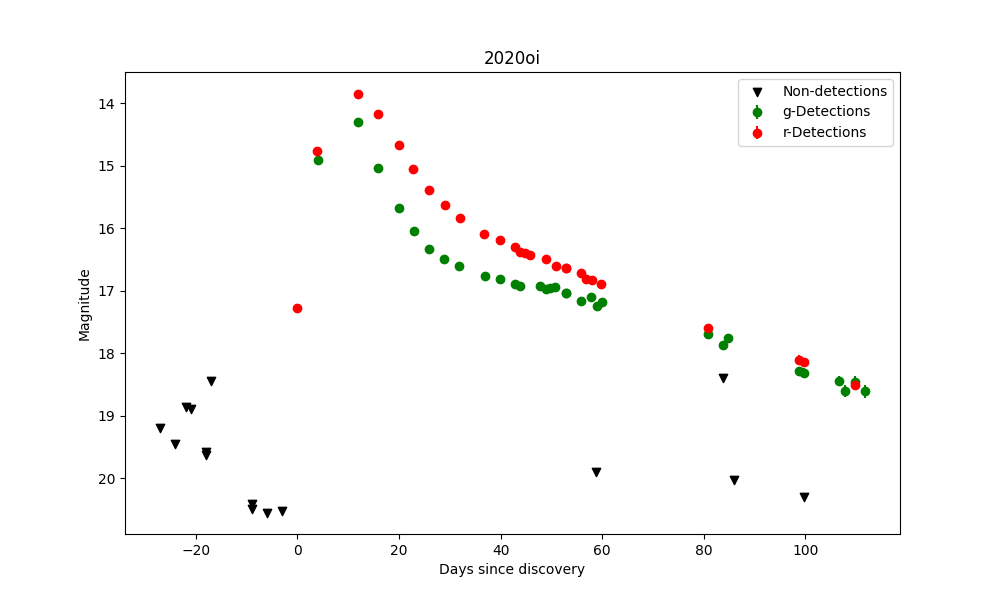

In [3]:
%matplotlib widget
from astropy.time import Time
from lasair_tools import plot_lightcurve
def get_sn_row(name):
    return tns_ibc[tns_ibc['name'] == name].iloc[0]
entry = get_sn_row('2020oi')
plot_lightcurve(entry['name'], Time(entry['discoverydate']).jd, epoch_after_discovery=1000)